In [1]:
# ============================================================
#  Train / Test Split 비교 데모
#  - [1] Iris        : Classification  (stratify=y)
#  - [2] Airline     : Time Series     (TimeSeriesSplit)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, TimeSeriesSplit


# ── 한글 폰트 없이도 깨지지 않도록 영문 레이블 사용 ──
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# ============================================================
# [1] CLASSIFICATION : Iris + stratify
# ============================================================
print("=" * 55)
print("[1] Classification : Iris Dataset")
print("=" * 55)

# 1-1. 데이터 로드
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

print(f"\n전체 샘플 수     : {len(y_iris)}")
print(f"클래스 분포 (전체):")
for cls, name in enumerate(iris.target_names):
    cnt = (y_iris == cls).sum()
    print(f"  {name:12s} : {cnt}개  ({cnt/len(y_iris)*100:.1f}%)")

# 1-2. stratify=y 로 분할
X_tr, X_te, y_tr, y_te = train_test_split(
    X_iris, y_iris,
    test_size=0.2,
    random_state=42,
    stratify=y_iris          # ← 클래스 비율 보존
)

print(f"\n분할 결과  →  Train: {len(y_tr)}개  |  Test: {len(y_te)}개")
print("\nTrain 클래스 분포:")
for cls, name in enumerate(iris.target_names):
    cnt = (y_tr == cls).sum()
    print(f"  {name:12s} : {cnt}개  ({cnt/len(y_tr)*100:.1f}%)")

print("\nTest 클래스 분포:")
for cls, name in enumerate(iris.target_names):
    cnt = (y_te == cls).sum()
    print(f"  {name:12s} : {cnt}개  ({cnt/len(y_te)*100:.1f}%)")

[1] Classification : Iris Dataset

전체 샘플 수     : 150
클래스 분포 (전체):
  setosa       : 50개  (33.3%)
  versicolor   : 50개  (33.3%)
  virginica    : 50개  (33.3%)

분할 결과  →  Train: 120개  |  Test: 30개

Train 클래스 분포:
  setosa       : 40개  (33.3%)
  versicolor   : 40개  (33.3%)
  virginica    : 40개  (33.3%)

Test 클래스 분포:
  setosa       : 10개  (33.3%)
  versicolor   : 10개  (33.3%)
  virginica    : 10개  (33.3%)


In [3]:
# 1-3. stratify 없는 경우와 비교
X_tr_no, X_te_no, y_tr_no, y_te_no = train_test_split(
    X_iris, y_iris,
    test_size=0.2,
    random_state=0             # ← stratify 없음
)
print("\n[참고] stratify 없을 때 Test 클래스 분포:")
for cls, name in enumerate(iris.target_names):
    cnt = (y_te_no == cls).sum()
    print(f"  {name:12s} : {cnt}개  ({cnt/len(y_te_no)*100:.1f}%)")


[참고] stratify 없을 때 Test 클래스 분포:
  setosa       : 11개  (36.7%)
  versicolor   : 13개  (43.3%)
  virginica    : 6개  (20.0%)


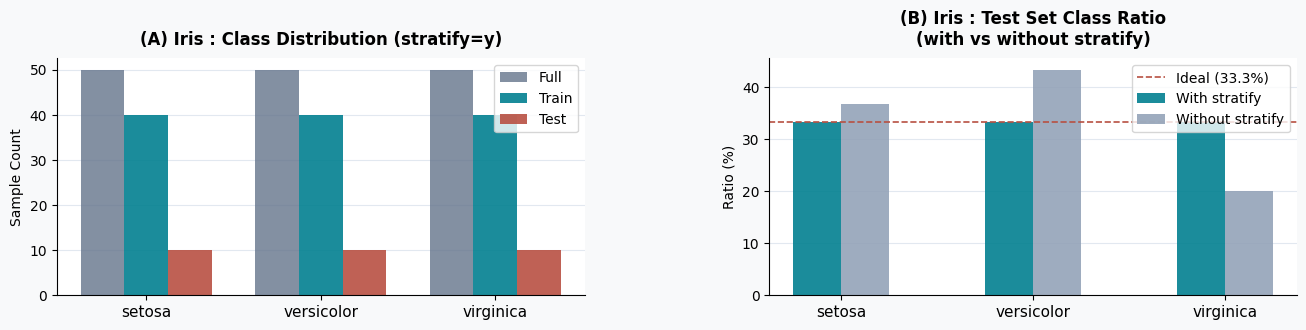

In [4]:
# ============================================================
# [3] 시각화
# ============================================================
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#F8F9FA')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

colors = {
    'setosa':     '#028090',
    'versicolor': '#E9A83A',
    'virginica':  '#B85042',
    'train':      '#028090',
    'test':       '#B85042',
    'grid':       '#E2E8F0',
}

# ── (A) Iris 클래스 분포 비교 ──
ax_a = fig.add_subplot(gs[0, 0])
ax_a.set_facecolor('white')
cls_names = iris.target_names
x = np.arange(len(cls_names))
w = 0.25
bars_full  = [(y_iris == c).sum()    for c in range(3)]
bars_train = [(y_tr == c).sum()      for c in range(3)]
bars_test  = [(y_te == c).sum()      for c in range(3)]

ax_a.bar(x - w, bars_full,  width=w, label='Full',  color='#64748B', alpha=0.8)
ax_a.bar(x,     bars_train, width=w, label='Train', color=colors['train'], alpha=0.9)
ax_a.bar(x + w, bars_test,  width=w, label='Test',  color=colors['test'],  alpha=0.9)
ax_a.set_xticks(x)
ax_a.set_xticklabels(cls_names, fontsize=11)
ax_a.set_title('(A) Iris : Class Distribution (stratify=y)', fontsize=12, fontweight='bold', pad=10)
ax_a.set_ylabel('Sample Count')
ax_a.legend(fontsize=10)
ax_a.yaxis.grid(True, color=colors['grid'], linewidth=0.8)
ax_a.set_axisbelow(True)
for spine in ['top', 'right']:
    ax_a.spines[spine].set_visible(False)

# ── (B) stratify 유무 비교 (Test set 비율) ──
ax_b = fig.add_subplot(gs[0, 1])
ax_b.set_facecolor('white')
ratio_with    = [(y_te    == c).sum() / len(y_te)    * 100 for c in range(3)]
ratio_without = [(y_te_no == c).sum() / len(y_te_no) * 100 for c in range(3)]
ax_b.bar(x - w/2, ratio_with,    width=w, label='With stratify',    color=colors['train'], alpha=0.9)
ax_b.bar(x + w/2, ratio_without, width=w, label='Without stratify', color='#94A3B8', alpha=0.9)
ax_b.axhline(33.3, color=colors['test'], linestyle='--', linewidth=1.2, label='Ideal (33.3%)')
ax_b.set_xticks(x)
ax_b.set_xticklabels(cls_names, fontsize=11)
ax_b.set_title('(B) Iris : Test Set Class Ratio\n(with vs without stratify)', fontsize=12, fontweight='bold', pad=10)
ax_b.set_ylabel('Ratio (%)')
ax_b.legend(fontsize=10)
ax_b.yaxis.grid(True, color=colors['grid'], linewidth=0.8)
ax_b.set_axisbelow(True)
for spine in ['top', 'right']:
    ax_b.spines[spine].set_visible(False)

In [5]:
# ============================================================
# [2] TIME SERIES : Airline + TimeSeriesSplit
# ============================================================
print("\n" + "=" * 55)
print("[2] Time Series : Airline Dataset (ARMA 전처리)")
print("=" * 55)

# 2-1. 데이터 로드 (AirPassengers 내장)
_passengers = [
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432,
]
airline = pd.Series(
    _passengers,
    index=pd.date_range("1949-01", periods=144, freq="MS"),
    name="passengers"
)

print(f"\n기간       : {airline.index[0].strftime('%Y-%m')} ~ "
      f"{airline.index[-1].strftime('%Y-%m')}")
print(f"총 관측치  : {len(airline)}개 (월별)")
print(f"최솟값     : {airline.min()}  |  최댓값: {airline.max()}")


[2] Time Series : Airline Dataset (ARMA 전처리)

기간       : 1949-01 ~ 1960-12
총 관측치  : 144개 (월별)
최솟값     : 104  |  최댓값: 622


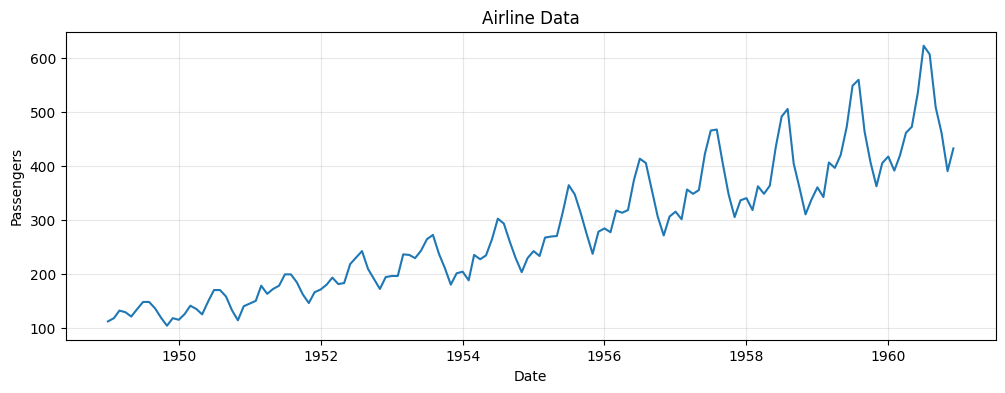

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(airline.index, airline.values)
plt.title("Airline Data")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.grid(alpha=0.3)
plt.show()

In [7]:
# 2-2. ARMA를 위한 로그 변환 + 차분 (분산 안정화)
log_airline = np.log(airline)
diff_airline = log_airline.diff().dropna()   # 1차 차분 → 정상성 확보

print(f"\n로그 변환 후 1차 차분 → 정상 시계열")
print(f"차분 후 관측치 수  : {len(diff_airline)}개")
print(f"차분 후 평균       : {diff_airline.mean():.4f}  (≈ 0 이면 정상)")
print(f"차분 후 표준편차   : {diff_airline.std():.4f}")




로그 변환 후 1차 차분 → 정상 시계열
차분 후 관측치 수  : 143개
차분 후 평균       : 0.0094  (≈ 0 이면 정상)
차분 후 표준편차   : 0.1066


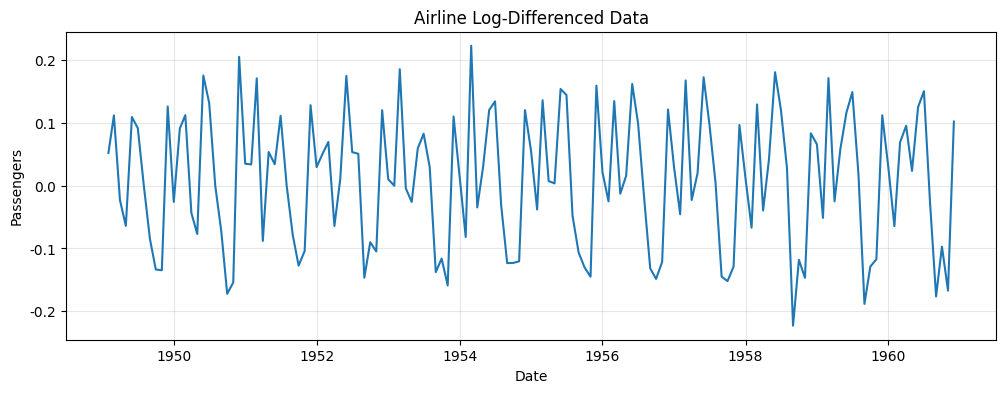

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(diff_airline.index, diff_airline.values)
plt.title("Airline Log-Differenced Data")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.grid(alpha=0.3)
plt.show()

In [9]:
# 2-3. 단순 Hold-out (마지막 24개월 = Test)
holdout_n = 24
train_hold = diff_airline.iloc[:-holdout_n]
test_hold  = diff_airline.iloc[-holdout_n:]

print(f"\n[Hold-out Split]")
print(f"  Train : {len(train_hold)}개  ({train_hold.index[0].strftime('%Y-%m')} ~ "
      f"{train_hold.index[-1].strftime('%Y-%m')})")
print(f"  Test  : {len(test_hold)}개   ({test_hold.index[0].strftime('%Y-%m')} ~ "
      f"{test_hold.index[-1].strftime('%Y-%m')})")

# 2-4. TimeSeriesSplit (5-fold)
tscv = TimeSeriesSplit(n_splits=5)

print(f"\n[TimeSeriesSplit  n_splits=5]")
for fold, (tr_idx, te_idx) in enumerate(tscv.split(diff_airline), 1):
    tr_data = diff_airline.iloc[tr_idx]
    te_data = diff_airline.iloc[te_idx]
    print(f"  Fold {fold}  Train: {len(tr_data):3d}개 "
          f"({tr_data.index[0].strftime('%Y-%m')}~{tr_data.index[-1].strftime('%Y-%m')})  "
          f"Test: {len(te_data):2d}개 "
          f"({te_data.index[0].strftime('%Y-%m')}~{te_data.index[-1].strftime('%Y-%m')})")





[Hold-out Split]
  Train : 119개  (1949-02 ~ 1958-12)
  Test  : 24개   (1959-01 ~ 1960-12)

[TimeSeriesSplit  n_splits=5]
  Fold 1  Train:  28개 (1949-02~1951-05)  Test: 23개 (1951-06~1953-04)
  Fold 2  Train:  51개 (1949-02~1953-04)  Test: 23개 (1953-05~1955-03)
  Fold 3  Train:  74개 (1949-02~1955-03)  Test: 23개 (1955-04~1957-02)
  Fold 4  Train:  97개 (1949-02~1957-02)  Test: 23개 (1957-03~1959-01)
  Fold 5  Train: 120개 (1949-02~1959-01)  Test: 23개 (1959-02~1960-12)


/var/folders/6r/ryg35lj50jg7mx0b5gtcd61c0000gn/T/ipykernel_83349/447863915.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


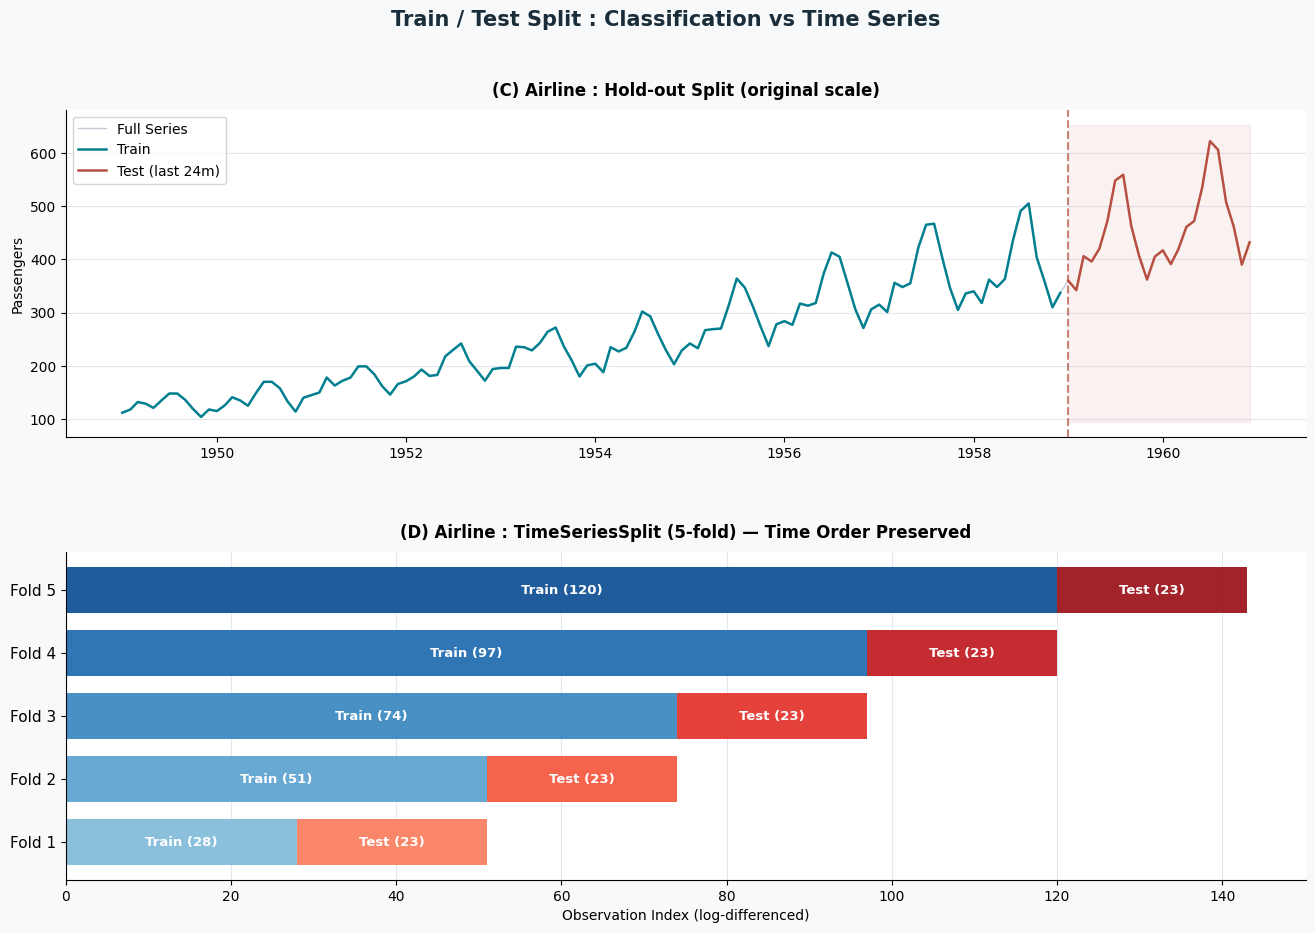


[완료] 시각화 저장 → train_test_split_demo.png


In [10]:
# ============================================================
# [3] 시각화
# ============================================================
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#F8F9FA')
gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.35)

colors = {
    'setosa':     '#028090',
    'versicolor': '#E9A83A',
    'virginica':  '#B85042',
    'train':      '#028090',
    'test':       '#B85042',
    'grid':       '#E2E8F0',
}

# ── (C) Airline 원본 + Hold-out 분할 ──
ax_c = fig.add_subplot(gs[0, 0])
ax_c.set_facecolor('white')
ax_c.plot(airline.index, airline.values, color='#64748B', linewidth=1.0, alpha=0.4, label='Full Series')
ax_c.plot(airline.index[:-holdout_n], airline.values[:-holdout_n],
          color=colors['train'], linewidth=1.8, label=f'Train')
ax_c.plot(airline.index[-holdout_n:], airline.values[-holdout_n:],
          color=colors['test'],  linewidth=1.8, label=f'Test (last {holdout_n}m)')
ax_c.axvline(test_hold.index[0], color=colors['test'], linestyle='--', linewidth=1.5, alpha=0.7)
ax_c.fill_betweenx([airline.min()*0.9, airline.max()*1.05],
                    test_hold.index[0], airline.index[-1],
                    color=colors['test'], alpha=0.07)
ax_c.set_title('(C) Airline : Hold-out Split (original scale)', fontsize=12, fontweight='bold', pad=10)
ax_c.set_ylabel('Passengers')
ax_c.legend(fontsize=10)
ax_c.yaxis.grid(True, color=colors['grid'], linewidth=0.8)
ax_c.set_axisbelow(True)
for spine in ['top', 'right']:
    ax_c.spines[spine].set_visible(False)

# ── (D) TimeSeriesSplit Fold 시각화 ──
ax_d = fig.add_subplot(gs[1, 0])
ax_d.set_facecolor('white')
folds = list(tscv.split(diff_airline))
train_palette = plt.cm.Blues(np.linspace(0.45, 0.9, len(folds)))
test_palette = plt.cm.Reds(np.linspace(0.45, 0.9, len(folds)))

for fold, (tr_idx, te_idx) in enumerate(folds):
    y_pos = fold * 1.1
    ax_d.barh(y_pos, len(tr_idx), left=0,          height=0.8,
              color=train_palette[fold], alpha=0.9)
    ax_d.barh(y_pos, len(te_idx), left=len(tr_idx), height=0.8,
              color=test_palette[fold],  alpha=0.9)
    ax_d.text(len(tr_idx) / 2,        y_pos, f'Train ({len(tr_idx)})',
              ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')
    ax_d.text(len(tr_idx) + len(te_idx) / 2, y_pos, f'Test ({len(te_idx)})',
              ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')

ax_d.set_yticks([i * 1.1 for i in range(len(folds))])
ax_d.set_yticklabels([f'Fold {i+1}' for i in range(len(folds))], fontsize=11)
ax_d.set_xlabel('Observation Index (log-differenced)')
ax_d.set_title('(D) Airline : TimeSeriesSplit (5-fold) — Time Order Preserved', fontsize=12, fontweight='bold', pad=10)
ax_d.xaxis.grid(True, color=colors['grid'], linewidth=0.8)
ax_d.set_axisbelow(True)
for spine in ['top', 'right']:
    ax_d.spines[spine].set_visible(False)

fig.suptitle('Train / Test Split : Classification vs Time Series',
             fontsize=15, fontweight='bold', y=0.98, color='#1A2D3A')
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('train_test_split_demo.png', dpi=150)
plt.show()
print("\n[완료] 시각화 저장 → train_test_split_demo.png")